In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [34]:
from src.dataloading.gnndataloader import GNNDataLoader

n_periods = 8
n_epochs  = 100
horizon   = 1
lags      = range(2,3)

influenza = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
influenza.add_time_features()
influenza.log_transform_target()
influenza.normalize('2018-06-01','2019-06-01','zscore')
influenza.add_lagged_features(lags)

noro = EpiDataLoader('norovirus', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
noro.add_time_features()
noro.log_transform_target()
noro.normalize('2018-06-01','2019-06-01','zscore')
noro.add_lagged_features(lags)

if 'population_size' in influenza.feature_columns:
    influenza.feature_columns.remove('population_size')

if 'population_size' in noro.feature_columns:
    noro.feature_columns.remove('population_size')

influenza_loader1 = GNNDataLoader(influenza).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
influenza_loader2 = GNNDataLoader(influenza).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
influenza_loader3 = GNNDataLoader(influenza).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)

noro_loader1 = GNNDataLoader(noro).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
noro_loader2 = GNNDataLoader(noro).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
noro_loader3 = GNNDataLoader(noro).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [22]:
from src.models.temporal_gcn import TemporalGCNModel

tGCN_idgraph = TemporalGCNModel(name = f'influenza_2', dataloader=influenza_loader2)
tGCN_idgraph.set_model_hparams()
tGCN_idgraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
tGCN_idgraph.train()
tGCN_idgraph.forecast()
tGCN_idgraph.show_forecasts()


Dataloader Snapshot: Data(x=[411, 4, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.8849, val loss: 2.0451 ✓ (new best)


KeyboardInterrupt: 

Dataloader Snapshot: Data(x=[411, 3, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.8246, val loss: 1.7314 ✓ (new best)
Epoch 2 train loss: 0.7904, val loss: 1.5896 ✓ (new best)
Epoch 3 train loss: 0.7595, val loss: 1.4425 ✓ (new best)
Epoch 4 train loss: 0.7357, val loss: 1.3216 ✓ (new best)
Epoch 5 train loss: 0.7196, val loss: 1.2424 ✓ (new best)
Epoch 6 train loss: 0.7101, val loss: 1.1943 ✓ (new best)
Epoch 7 train loss: 0.7032, val loss: 1.1633 ✓ (new best)
Epoch 8 train loss: 0.6967, val loss: 1.1398 ✓ (new best)
Epoch 9 train loss: 0.6931, val loss: 1.1224 ✓ (new best)
Epoch 10 train loss: 0.6893, val loss: 1.1270 (patience: 1/15)
Epoch 11 train loss: 0.6829, val loss: 1.1137 ✓ (new best)
Epoch 12 train loss: 0.6779, val loss: 1.1018 ✓ (new best)
Epoch 13 train loss: 0.6741, val loss: 1.0902 ✓ (new best)
Epoch 14 train loss: 0.6717, val loss: 1.0816 ✓ (new best)
Epoch 15 train loss: 0.6690, val loss: 1.0733 ✓ (new best)
Epoch 16 train loss: 0.66

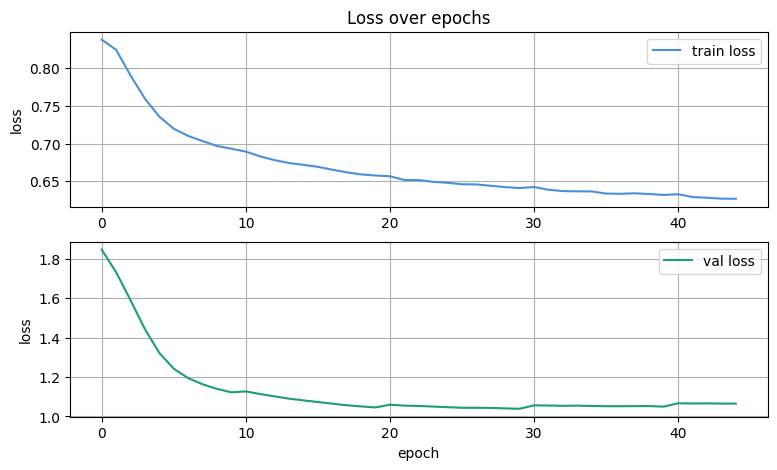

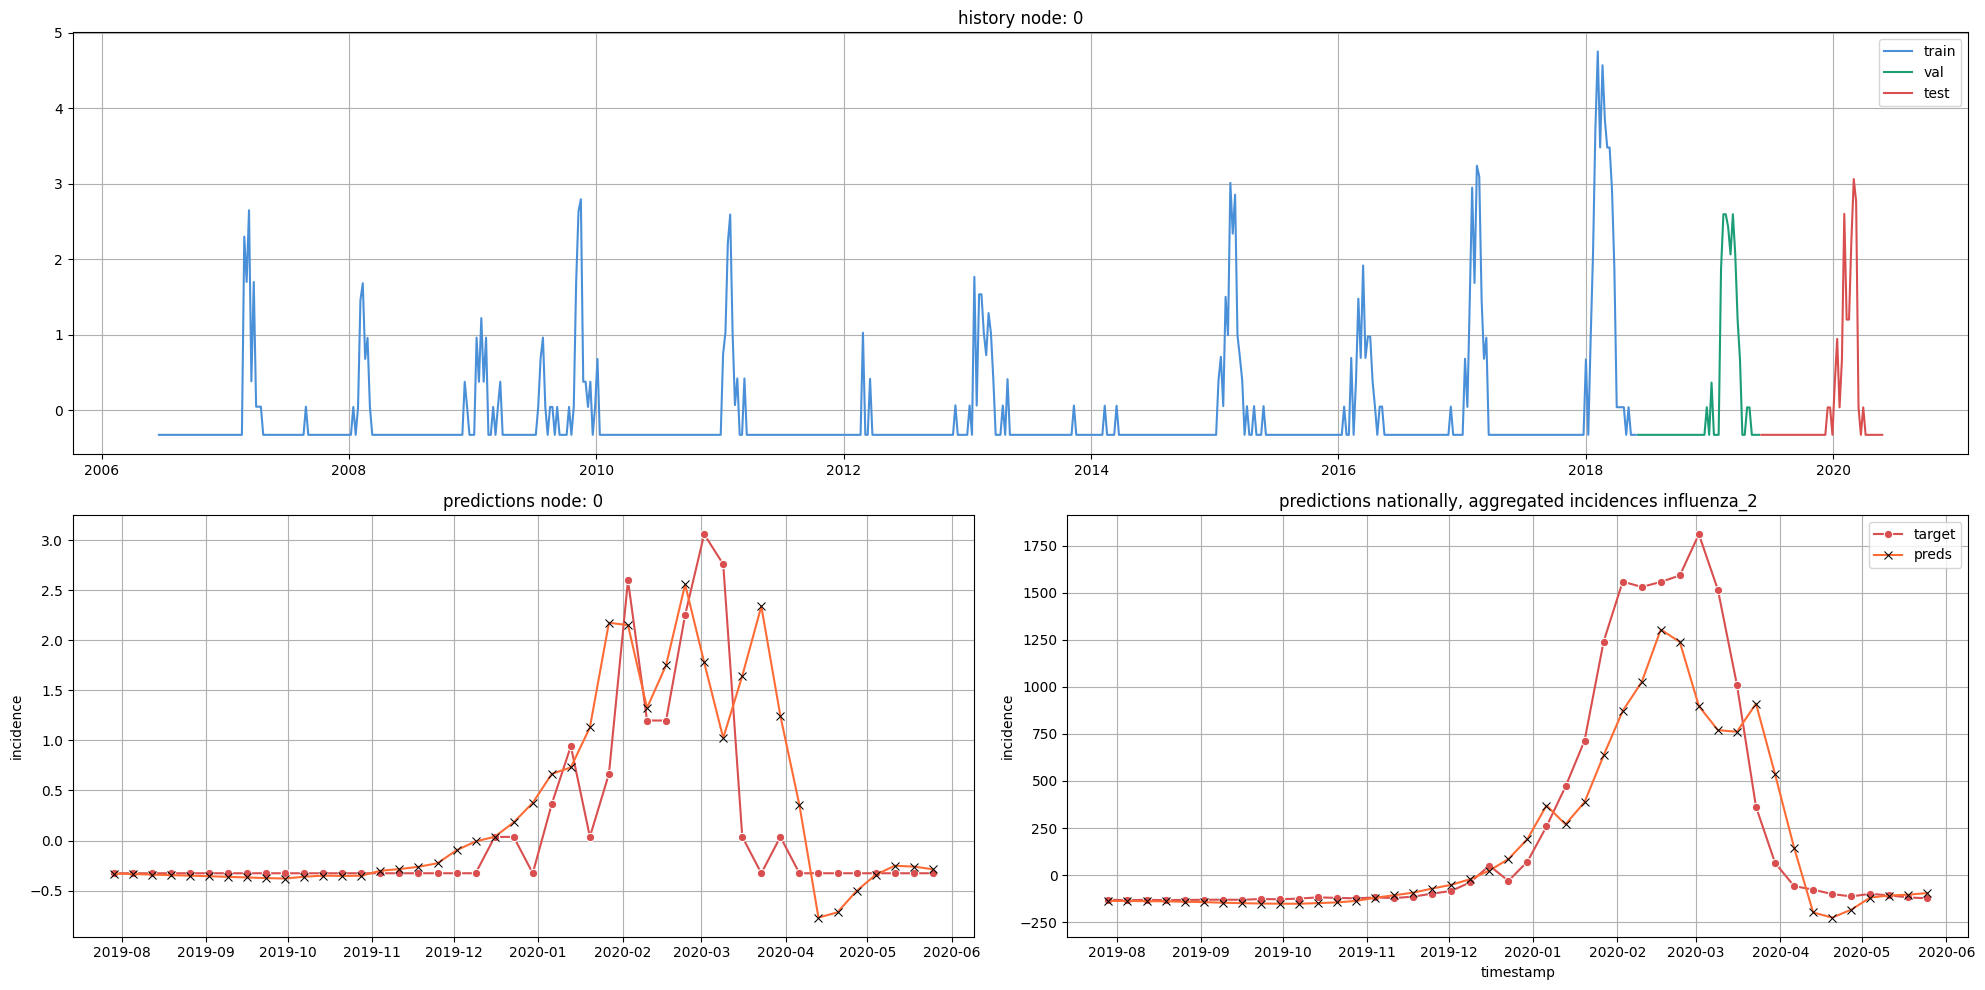

In [41]:
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

tGCN_idgraph = PaperGRU_GATv2_Model_Wrapper(name = f'influenza_2', dataloader=influenza_loader2)
tGCN_idgraph.set_model_hparams()
tGCN_idgraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.00001, loss = 'mse')
tGCN_idgraph.train()
tGCN_idgraph.forecast()
tGCN_idgraph.show_forecasts()

Dataloader Snapshot: Data(x=[411, 3, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 0.9222, val loss: 1.3142 ✓ (new best)
Epoch 2 train loss: 0.8583, val loss: 1.3014 ✓ (new best)
Epoch 3 train loss: 0.8527, val loss: 1.1342 ✓ (new best)
Epoch 4 train loss: 0.8502, val loss: 1.1213 ✓ (new best)
Epoch 5 train loss: 0.8664, val loss: 1.1259 (patience: 1/15)
Epoch 6 train loss: 0.8282, val loss: 1.0758 ✓ (new best)
Epoch 7 train loss: 0.8278, val loss: 1.1152 (patience: 1/15)
Epoch 8 train loss: 0.8325, val loss: 1.0669 ✓ (new best)
Epoch 9 train loss: 0.8301, val loss: 1.0436 ✓ (new best)
Epoch 10 train loss: 0.8180, val loss: 1.1213 (patience: 1/15)
Epoch 11 train loss: 0.8231, val loss: 1.0605 (patience: 2/15)
Epoch 12 train loss: 0.8241, val loss: 1.0191 ✓ (new best)
Epoch 13 train loss: 0.8222, val loss: 1.1946 (patience: 1/15)
Epoch 14 train loss: 0.8252, val loss: 1.0788 (patience: 2/15)
Epoch 15 train loss: 0.8275, val loss: 1.0290 (patience: 3/15)
Epo

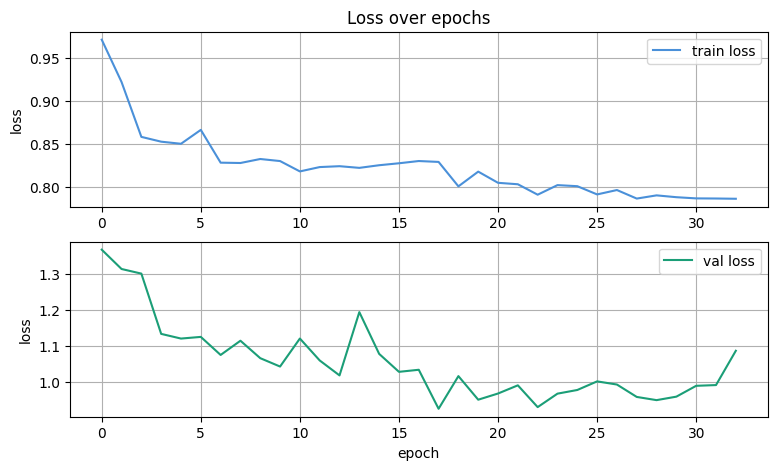

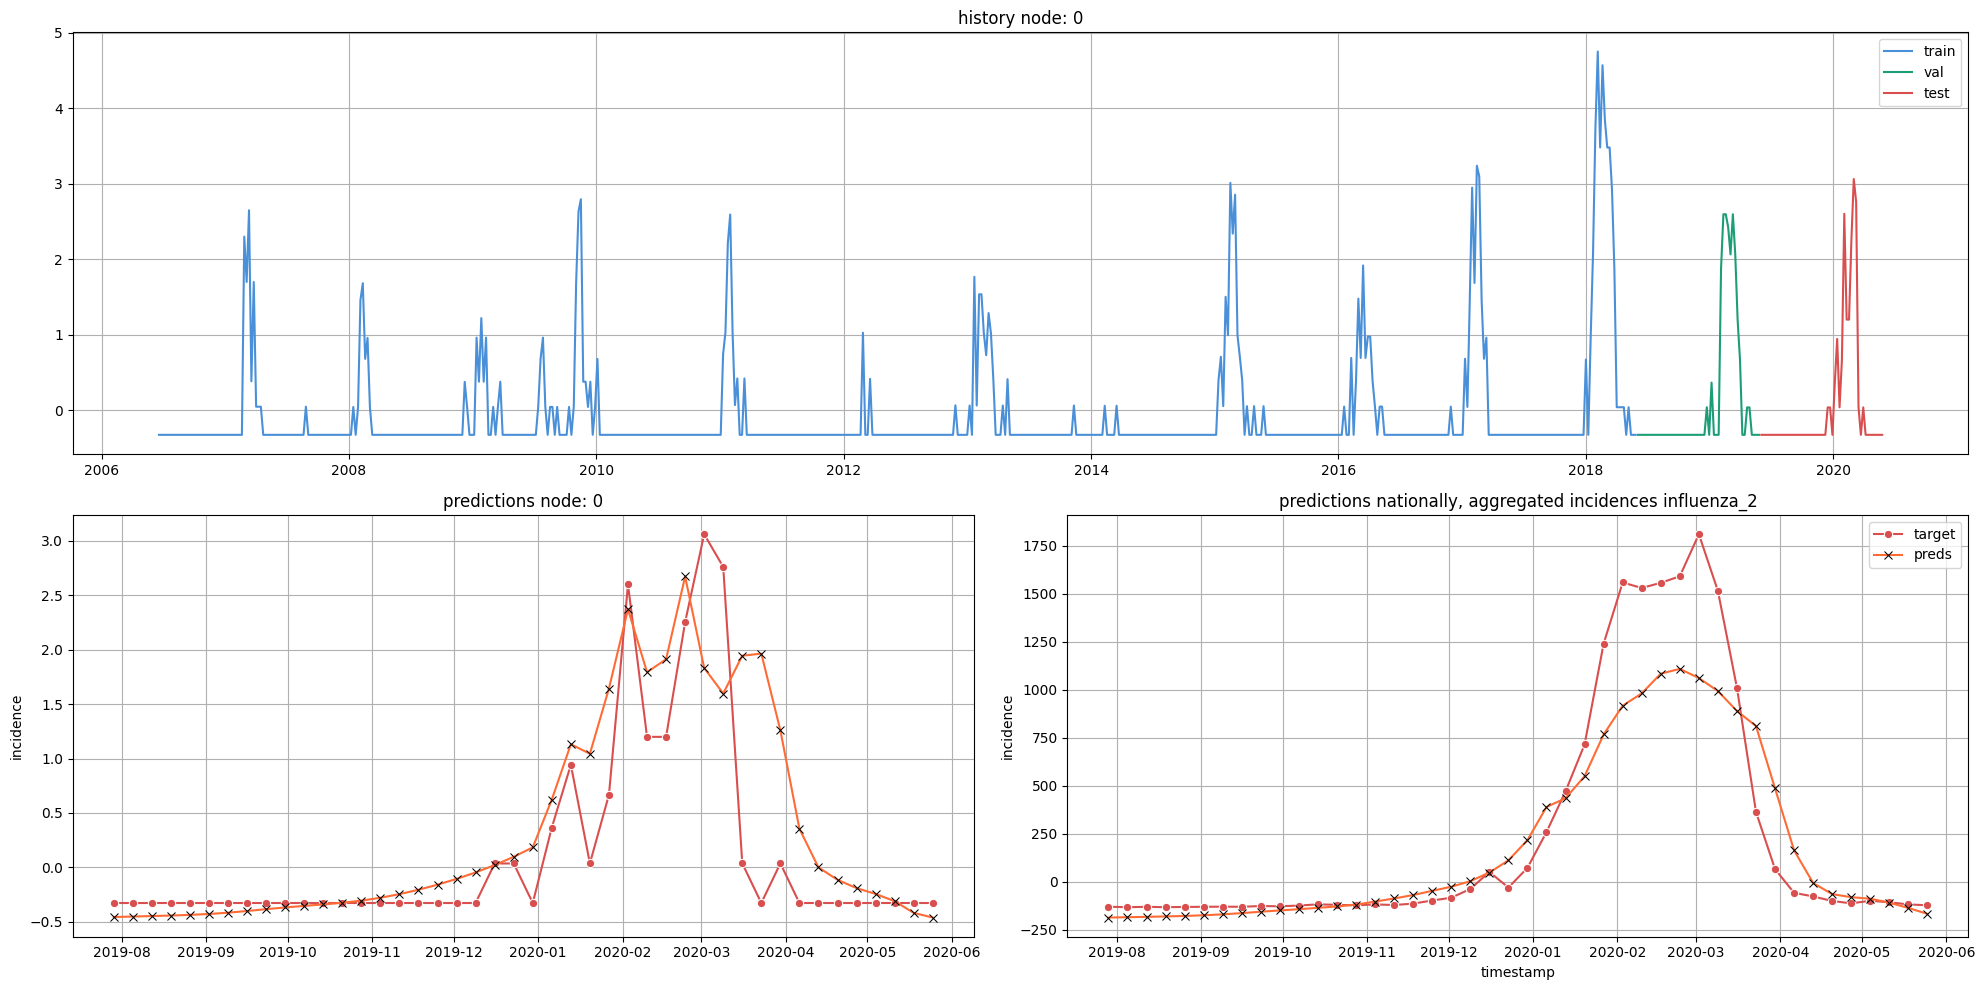

In [43]:
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

tGCN_idgraph = PaperGRU_GATv2_Model_Wrapper(name = f'influenza_2', dataloader=influenza_loader1)
tGCN_idgraph.set_model_hparams()
tGCN_idgraph.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.00001, loss = 'mse')
tGCN_idgraph.train()
tGCN_idgraph.forecast()
tGCN_idgraph.show_forecasts()

In [37]:
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

tGCN_idgraph = PaperGRU_GATv2_Model_Wrapper(name = f'noro_2', dataloader=noro_loader2)
tGCN_idgraph.set_model_hparams()
tGCN_idgraph.set_global_hparams(lr = 0.000001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.6}, min_delta = 0.00001, loss = 'mse')
tGCN_idgraph.train()
tGCN_idgraph.forecast()
tGCN_idgraph.show_forecasts()

Dataloader Snapshot: Data(x=[411, 3, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 1.2860, val loss: 0.8466 ✓ (new best)
Epoch 2 train loss: 1.2393, val loss: 0.8170 ✓ (new best)
Epoch 3 train loss: 1.1956, val loss: 0.7898 ✓ (new best)
Epoch 4 train loss: 1.1548, val loss: 0.7648 ✓ (new best)
Epoch 5 train loss: 1.1166, val loss: 0.7418 ✓ (new best)
Epoch 6 train loss: 1.0806, val loss: 0.7206 ✓ (new best)
Epoch 7 train loss: 1.0471, val loss: 0.7012 ✓ (new best)
Epoch 8 train loss: 1.0154, val loss: 0.6836 ✓ (new best)
Epoch 9 train loss: 0.9857, val loss: 0.6676 ✓ (new best)
Epoch 10 train loss: 0.9629, val loss: 0.6588 ✓ (new best)
Epoch 11 train loss: 0.9469, val loss: 0.6506 ✓ (new best)
Epoch 12 train loss: 0.9315, val loss: 0.6430 ✓ (new best)
Epoch 13 train loss: 0.9168, val loss: 0.6360 ✓ (new best)
Epoch 14 train loss: 0.9031, val loss: 0.6297 ✓ (new best)
Epoch 15 train loss: 0.8902, val loss: 0.6239 ✓ (new best)
Epoch 16 train loss: 0.8777, 

KeyboardInterrupt: 